# 02 - Segmentación de un frame con SAM 3

Este notebook valida la inferencia de SAM 3 sobre un solo frame del video de prueba.

Objetivos:

1. Verificar el ambiente de ejecución.
2. Cargar un frame extraído del clip corto.
3. Inicializar SAM 3.
4. Ejecutar segmentación con prompts de texto.
5. Visualizar máscaras sobre el frame.
6. Guardar resultados preliminares en `outputs/figures/`.

Este notebook no procesa video completo. Primero se valida la segmentación en una sola imagen.


In [1]:
from pathlib import Path
import sys
import os

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memoria total [GB]:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Python: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Memoria total [GB]: 8.0


In [2]:
# Rutas principales.
# Si Jupyter fue abierto desde la raíz del repositorio, esta ruta debe funcionar.
PROJECT_ROOT = Path.cwd()
num = 127

# Si por alguna razón el notebook se abrió desde notebooks/, ajustar automáticamente.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FRAME_DIR = PROJECT_ROOT / "data" / "frames" / "test_20s"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Carpeta de frames:", FRAME_DIR)

frames = sorted(FRAME_DIR.glob("*.jpg"))

print("Frames encontrados:", len(frames))

if len(frames) == 0:
    raise FileNotFoundError(f"No se encontraron frames en: {FRAME_DIR}")

FRAME_PATH = frames[num]
print("Frame seleccionado:", FRAME_PATH)


Raíz del proyecto: /home/eduar/projects/copa-fut-bot-mx-pumas-ae
Carpeta de frames: /home/eduar/projects/copa-fut-bot-mx-pumas-ae/data/frames/test_20s
Frames encontrados: 200
Frame seleccionado: /home/eduar/projects/copa-fut-bot-mx-pumas-ae/data/frames/test_20s/frame_000128.jpg


Dimensiones del frame: (1276, 960, 3)


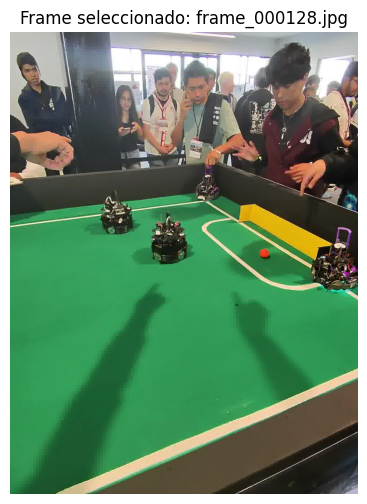

In [3]:
# Cargar y visualizar el frame seleccionado.

image_bgr = cv2.imread(str(FRAME_PATH))

if image_bgr is None:
    raise RuntimeError(f"No se pudo leer la imagen: {FRAME_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Dimensiones del frame:", image_rgb.shape)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title(f"Frame seleccionado: {FRAME_PATH.name}")
plt.show()


## Inicialización de SAM 3

La siguiente celda inicializa el modelo de imagen de SAM 3 y su procesador. La primera ejecución puede tardar porque puede descargar pesos del modelo desde Hugging Face.

Si aparece un error de acceso, revisa que:

1. Iniciaste sesión con `hf auth login`.
2. Tu cuenta tiene acceso autorizado al modelo de SAM 3 en Hugging Face.
3. El ambiente activo es `futbotmx-sam3`.


In [4]:
# Parche temporal para incompatibilidades de dtype en SAM 3.
# Debe ejecutarse antes de importar/inicializar SAM 3.

import torch
import torch.nn.functional as F

_ORIGINAL_LINEAR = F.linear

def _safe_linear(input, weight, bias=None):
    if input.dtype != weight.dtype:
        input = input.to(dtype=weight.dtype)
    return _ORIGINAL_LINEAR(input, weight, bias)

F.linear = _safe_linear

print("Parche temporal aplicado: F.linear convierte input al dtype de weight.")

Parche temporal aplicado: F.linear convierte input al dtype de weight.


In [5]:
from contextlib import nullcontext

from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
CONFIDENCE_THRESHOLD = 0.05

print("Dispositivo usado:", DEVICE)
print("Dtype solicitado:", DTYPE)

try:
    model = build_sam3_image_model(device=DEVICE)
except TypeError:
    model = build_sam3_image_model()

model = model.to(device=DEVICE, dtype=DTYPE)
model.eval()

processor = Sam3Processor(model, confidence_threshold=CONFIDENCE_THRESHOLD)

dtype_counts = {}
for _, p in model.named_parameters():
    dtype_counts[str(p.dtype)] = dtype_counts.get(str(p.dtype), 0) + 1

print("Dtypes en parámetros del modelo:")
for dtype_name, count in dtype_counts.items():
    print(f"  {dtype_name}: {count}")

first_param = next(model.parameters())
print("Primer parámetro:")
print("  dtype:", first_param.dtype)
print("  device:", first_param.device)

print("SAM 3 inicializado correctamente.")

/home/eduar/miniconda3/envs/futbotmx-sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Dispositivo usado: cuda
Dtype solicitado: torch.bfloat16
Dtypes en parámetros del modelo:
  torch.bfloat16: 1102
Primer parámetro:
  dtype: torch.bfloat16
  device: cuda:0
SAM 3 inicializado correctamente.


/home/eduar/miniconda3/envs/futbotmx-sam3/lib/python3.12/site-packages/torch/nn/modules/module.py:1370: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  return t.to(


In [6]:
def to_numpy(x):
    """Convierte tensores/listas de SAM 3 a NumPy de forma segura."""
    if x is None:
        return None

    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()

        # NumPy no soporta directamente torch.bfloat16.
        if x.dtype in (torch.bfloat16, torch.float16):
            x = x.float()

        return x.numpy()

    return np.asarray(x)


def summarize_sam_output(output):
    """Imprime un resumen básico del resultado de SAM 3."""
    print("Claves del resultado:", list(output.keys()))

    for key in ["masks", "boxes", "scores"]:
        if key in output:
            arr = to_numpy(output[key])
            print(f"{key}: shape={None if arr is None else arr.shape}, dtype={None if arr is None else arr.dtype}")


def prepare_masks(masks):
    """Normaliza máscaras a forma [N, H, W]."""
    masks_np = to_numpy(masks)

    if masks_np is None:
        return np.empty((0, image_rgb.shape[0], image_rgb.shape[1]), dtype=bool)

    masks_np = np.asarray(masks_np)

    if masks_np.size == 0:
        return np.empty((0, image_rgb.shape[0], image_rgb.shape[1]), dtype=bool)

    # Casos frecuentes: [N, 1, H, W] o [N, H, W].
    if masks_np.ndim == 4 and masks_np.shape[1] == 1:
        masks_np = masks_np[:, 0, :, :]
    elif masks_np.ndim == 2:
        masks_np = masks_np[None, :, :]

    # Si la máscara viene como probabilidad o logit, convertir a booleana.
    if masks_np.dtype != bool:
        masks_np = masks_np > 0

    return masks_np.astype(bool)


def show_masks(image_rgb, masks, title="", max_masks=20):
    """Muestra máscaras superpuestas sobre la imagen."""
    masks_np = prepare_masks(masks)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)

    if masks_np.shape[0] == 0:
        plt.title(title + " | Sin máscaras")
        plt.axis("off")
        plt.show()
        return

    for i, mask in enumerate(masks_np[:max_masks]):
        overlay = np.zeros((*mask.shape, 4), dtype=float)
        overlay[..., 3] = mask * 0.45
        plt.imshow(overlay)

    plt.title(f"{title} | Máscaras mostradas: {min(masks_np.shape[0], max_masks)}")
    plt.axis("off")
    plt.show()


Claves del resultado: ['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores']
masks: shape=(15, 1, 1276, 960), dtype=bool
boxes: shape=(15, 4), dtype=float32
scores: shape=(15,), dtype=float32


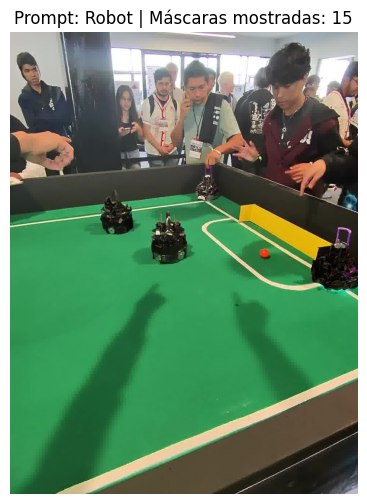

In [18]:
PROMPT = "Robot"

image_pil = Image.open(FRAME_PATH).convert("RGB")

autocast_context = (
    torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=True)
    if DEVICE == "cuda"
    else nullcontext()
)

with torch.inference_mode(), autocast_context:
    state = processor.set_image(image_pil)
    output = processor.set_text_prompt(state=state, prompt=PROMPT)

summarize_sam_output(output)
show_masks(image_rgb, output.get("masks"), title=f"Prompt: {PROMPT}")

In [10]:
# Guardar una figura preliminar del resultado.

def save_overlay_figure(image_rgb, masks, output_path, title=""):
    masks_np = prepare_masks(masks)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)

    for mask in masks_np[:20]:
        overlay = np.zeros((*mask.shape, 4), dtype=float)
        overlay[..., 3] = mask * 0.45
        plt.imshow(overlay)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()

    print("Figura guardada en:", output_path)


safe_prompt = PROMPT.replace(" ", "_").replace("/", "_")
output_path = OUTPUT_FIGURES_DIR / f"sam3_{safe_prompt}_{FRAME_PATH.stem}.png"

save_overlay_figure(
    image_rgb=image_rgb,
    masks=output.get("masks"),
    output_path=output_path,
    title=f"SAM 3 | Prompt: {PROMPT}"
)


Figura guardada en: /home/eduar/projects/copa-fut-bot-mx-pumas-ae/outputs/figures/sam3_ball_frame_000128.png


In [13]:
# Prueba comparativa con varios prompts.
# Esta celda ayuda a identificar qué prompts funcionan mejor para el dominio del reto.

prompts = [
    "robot",
    "mobile robot",
    "black robot",
    "robot soccer player",
    "playing field",
    "goal",
    "yellow goal",
]

results = {}

image_pil = Image.open(FRAME_PATH).convert("RGB")

with torch.inference_mode(), autocast_context:
    state = processor.set_image(image_pil)

    for prompt in prompts:
        print("\nPrompt:", prompt)

        output = processor.set_text_prompt(state=state, prompt=prompt)
        results[prompt] = output

        summarize_sam_output(output)

        n_masks = 0
        if output.get("masks") is not None:
            n_masks = output["masks"].shape[0]

        print("Número de máscaras:", n_masks)



Prompt: robot
Claves del resultado: ['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores']
masks: shape=(15, 1, 1276, 960), dtype=bool
boxes: shape=(15, 4), dtype=float32
scores: shape=(15,), dtype=float32
Número de máscaras: 15

Prompt: mobile robot
Claves del resultado: ['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores']
masks: shape=(0, 1, 1276, 960), dtype=bool
boxes: shape=(0, 4), dtype=float32
scores: shape=(0,), dtype=float32
Número de máscaras: 0

Prompt: black robot
Claves del resultado: ['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores']
masks: shape=(0, 1, 1276, 960), dtype=bool
boxes: shape=(0, 4), dtype=float32
scores: shape=(0,), dtype=float32
Número de máscaras: 0

Prompt: robot soccer player
Claves del resultado: ['original_height', 'original_width', 'backbone_out', 'geometric_

In [14]:
for prompt, output in results.items():
    masks = output.get("masks")

    if masks is None or masks.shape[0] == 0:
        print(f"Sin detección para prompt: {prompt}")
        continue

    show_masks(
        image_rgb=image_rgb,
        masks=masks,
        title=f"Prompt: {prompt}",
        max_masks=10,
    )

Sin detección para prompt: robot
Sin detección para prompt: mobile robot
Sin detección para prompt: black robot
Sin detección para prompt: robot soccer player
Sin detección para prompt: playing field
Sin detección para prompt: goal
Sin detección para prompt: yellow goal


In [ ]:
# Guardar figuras de todos los prompts exitosos.

for prompt, out in results.items():
    if out is None:
        continue

    safe_prompt = prompt.replace(" ", "_").replace("/", "_")
    output_path = OUTPUT_FIGURES_DIR / f"sam3_{safe_prompt}_{FRAME_PATH.stem}.png"

    save_overlay_figure(
        image_rgb=image_rgb,
        masks=out.get("masks"),
        output_path=output_path,
        title=f"SAM 3 | Prompt: {prompt}"
    )
